# EDA and data preprocessing

- Trong phần này, chúng ta sẽ phân tích các đặc trưng của bộ dữ liệu, từ đó đưa ra phương pháp hợp lí để xử lý dữ liệu, giúp mô hình có thể học tốt hơn. Cụ thể, với bộ dữ liệu này, ngoài một số thông tin cơ bản, chúng ta sẽ kiểm tra và xử lý:

    - Data duplication
    - Missing values
    - Outliers
    - Features correlation
    - Data imbalance (Optional?)


In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
datapath = r'D:\2025-2026\HK2-2025-2026\CS114\DoAn\parkinsons+telemonitoring\parkinsons_updrs.data'
df = pd.read_csv(datapath)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5875, 22)


,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR     

+ Qua hàm df.info(), ta biết được một số thông tin sau:
    + Dữ liệu có 22 đặc trưng với 5875 mẫu. Trong đó, motor_UPDRS và total_UPDRS là biến mục tiêu.
    + Tất cả dữ liệu đều ở dạng số thực hoặc số nguyên.
    + Bộ dữ liệu không có dữ liệu bị thiếu.

Tiếp theo, chúng ta sẽ kiểm tra dữ liệu trùng lặp.

In [6]:
print(f'Number of duplicated rows: {df.duplicated().sum()}')
target = ['motor_UPDRS', 'total_UPDRS']
features = [col for col in df.columns if col not in target]
print(f'Number of duplicated features rows: {df[features].duplicated().sum()}')

Number of duplicated rows: 0
Number of duplicated features rows: 0


Như vậy, bộ dữ liệu không có dữ liệu bị trùng. 

Tiếp theo, chúng ta sẽ kiểm tra phân phối của dữ liệu. Chúng ta cũng sẽ kiểm tra sự tương quan (correlation) giữa các đặc trưng với nhau và với biến mục tiêu để xác định những đặc trưng nào có thể có ảnh hưởng lớn đến kết quả dự đoán.

In [7]:
drop_df = df.drop(columns=['subject#'])
drop_df.describe()

,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,0.034035,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,0.025835,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,0.003060,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,0.019120,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,0.027510,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,0.039750,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,0.268630,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


In [8]:
corr = df.corr()

corr_upper = corr.where(np.triu(np.ones_like(corr), k=1).astype(bool))
corr_pairs = corr_upper.unstack().dropna()

sorted_pairs = corr_pairs.sort_index()
strong_pairs = sorted_pairs[abs(sorted_pairs) > 0.8]

for (feat1, feat2), corr_val in strong_pairs.items():
    print(f"{feat1} - {feat2}: {corr_val:.6f}")

HNR - Shimmer: -0.801416
HNR - Shimmer(dB): -0.802496
Jitter(Abs) - Jitter(%): 0.865577
Jitter:DDP - Jitter(%): 0.984184
Jitter:DDP - Jitter(Abs): 0.844630
Jitter:DDP - Jitter:PPQ5: 0.947203
Jitter:DDP - Jitter:RAP: 1.000000
Jitter:PPQ5 - Jitter(%): 0.968214
Jitter:PPQ5 - Jitter:RAP: 0.947196
Jitter:RAP - Jitter(%): 0.984181
Jitter:RAP - Jitter(Abs): 0.844626
NHR - Jitter(%): 0.825294
NHR - Jitter:PPQ5: 0.864864
Shimmer(dB) - Shimmer: 0.992334
Shimmer:APQ11 - Shimmer: 0.935457
Shimmer:APQ11 - Shimmer(dB): 0.936338
Shimmer:APQ11 - Shimmer:APQ3: 0.885695
Shimmer:APQ11 - Shimmer:APQ5: 0.938935
Shimmer:APQ3 - Shimmer: 0.979828
Shimmer:APQ3 - Shimmer(dB): 0.968015
Shimmer:APQ5 - Shimmer: 0.984904
Shimmer:APQ5 - Shimmer(dB): 0.976373
Shimmer:APQ5 - Shimmer:APQ3: 0.962723
Shimmer:DDA - Shimmer: 0.979827
Shimmer:DDA - Shimmer(dB): 0.968014
Shimmer:DDA - Shimmer:APQ11: 0.885694
Shimmer:DDA - Shimmer:APQ3: 1.000000
Shimmer:DDA - Shimmer:APQ5: 0.962723
total_UPDRS - motor_UPDRS: 0.947231


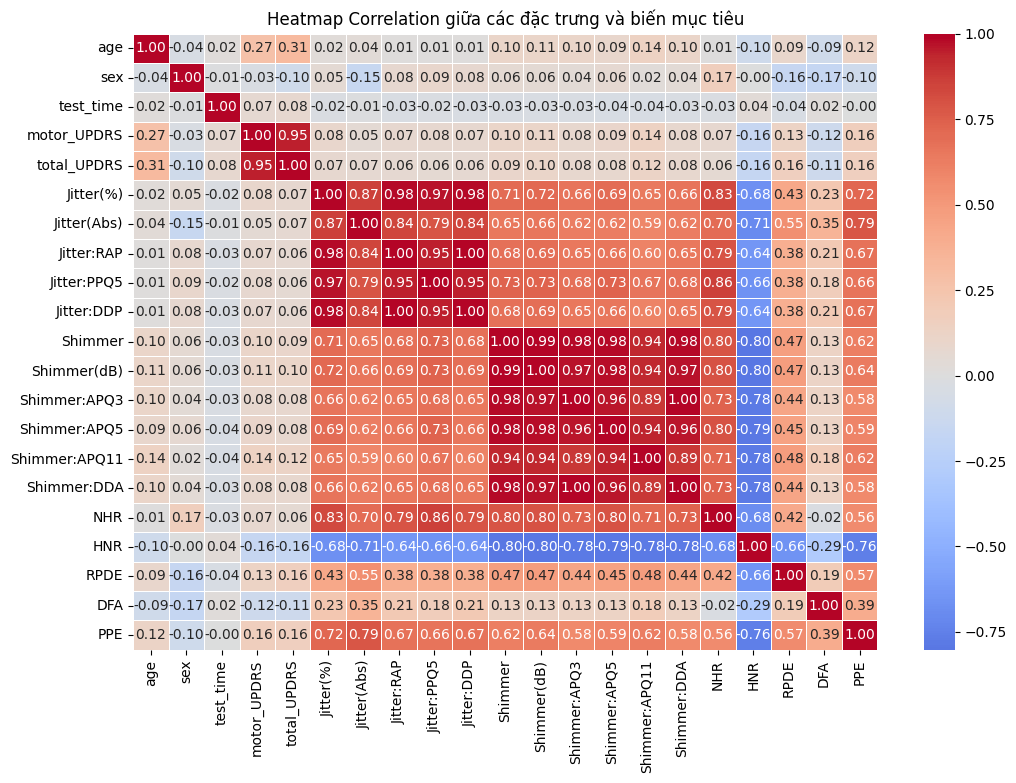

In [10]:
plt.figure(figsize=(12, 8))
# Tính toán lại correlation trên df đã xử lý (đã gộp Jitter/Shimmer và drop 'sex')
corr_matrix = df.drop(columns=['subject#']).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center = 0)
plt.title('Heatmap Correlation giữa các đặc trưng và biến mục tiêu')
plt.show()

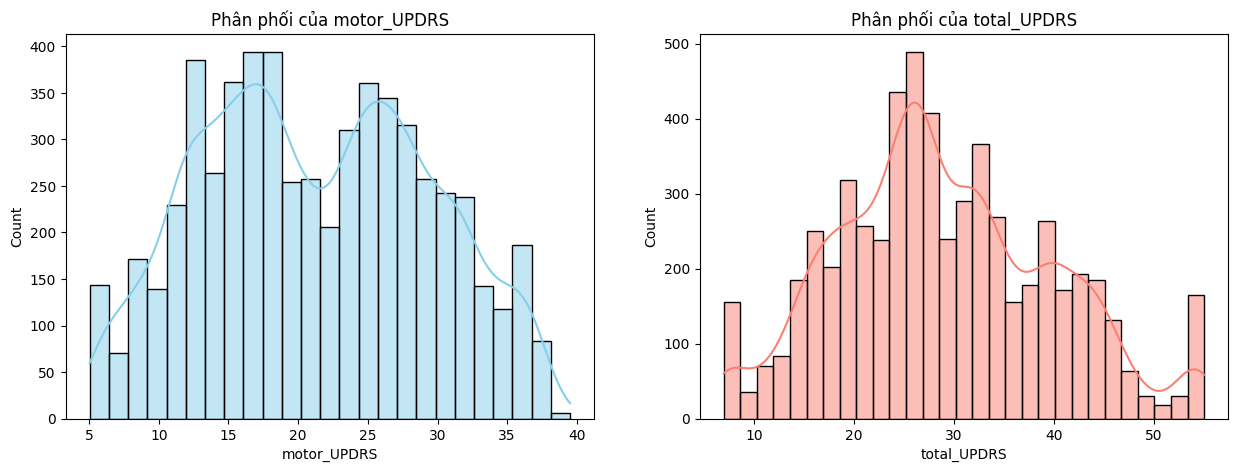

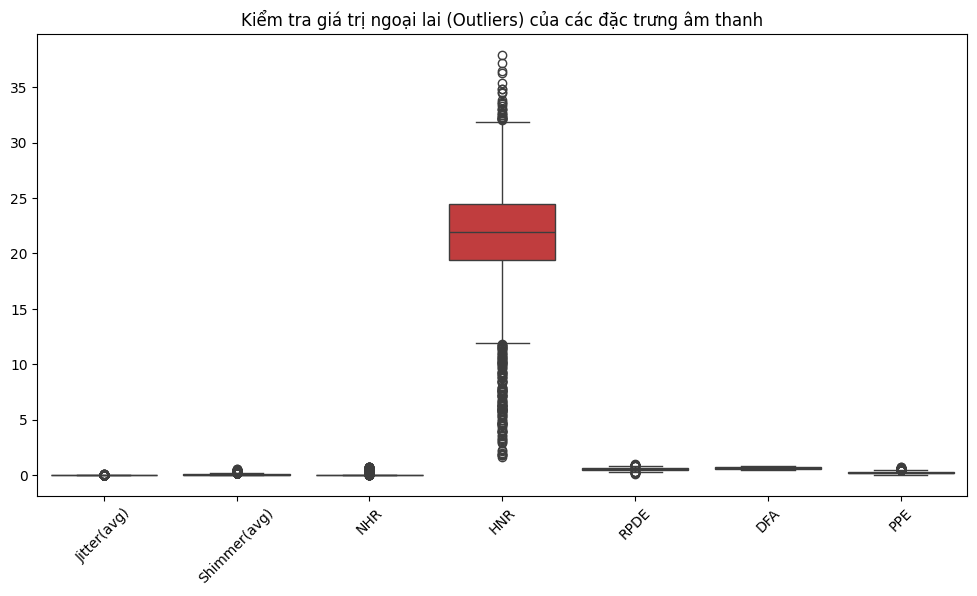

In [15]:
# Vẽ phân phối cho 2 biến mục tiêu
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['motor_UPDRS'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của motor_UPDRS')

sns.histplot(df['total_UPDRS'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối của total_UPDRS')

plt.show()

# Vẽ boxplot để kiểm tra Outliers cho các đặc trưng âm thanh chính
plt.figure(figsize=(12, 6))
features_to_plot = ['Jitter(avg)', 'Shimmer(avg)', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
sns.boxplot(data=df[features_to_plot])
plt.title('Kiểm tra giá trị ngoại lai (Outliers) của các đặc trưng âm thanh')
plt.xticks(rotation=45)
plt.show()

In [16]:
print(df[['total_UPDRS', 'motor_UPDRS']].corr())

             total_UPDRS  motor_UPDRS
total_UPDRS     1.000000     0.947231
motor_UPDRS     0.947231     1.000000


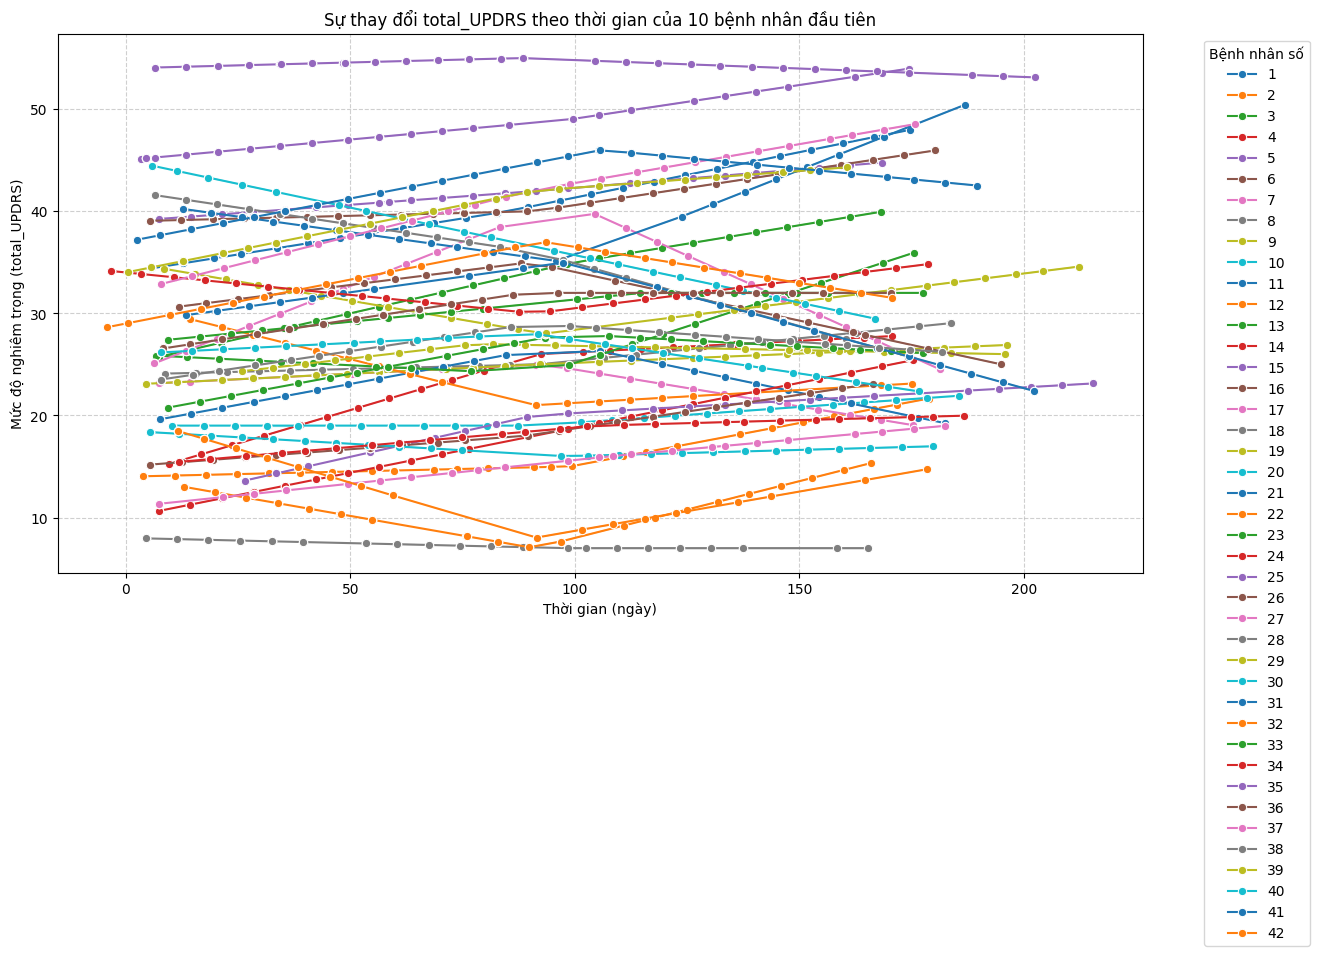

In [18]:
# Chọn ra khoảng 10 bệnh nhân đầu tiên để so sánh tiến triển
sample_subjects = df['subject#'].unique()[:42]
df_sample = df[df['subject#'].isin(sample_subjects)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_sample, x='test_time', y='total_UPDRS', hue='subject#', palette='tab10', marker='o')

plt.title('Sự thay đổi total_UPDRS theo thời gian của 10 bệnh nhân đầu tiên')
plt.xlabel('Thời gian (ngày)')
plt.ylabel('Mức độ nghiêm trọng (total_UPDRS)')
plt.legend(title='Bệnh nhân số', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
df['Jitter(avg)'] = df[['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']].mean(axis=1)
df['Shimmer(avg)'] = df[['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']].mean(axis=1)
df = df.drop(columns=['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                      'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA'])

drop_df = df.drop(columns=['subject#'])
drop_df.describe()

,age,sex,test_time,motor_UPDRS,total_UPDRS,NHR,HNR,RPDE,DFA,PPE,Jitter(avg),Shimmer(avg)
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,64.804936,0.317787,92.863722,21.296229,29.018942,0.032120,21.679495,0.541473,0.653240,0.219589,0.004285,0.076874
std,8.821524,0.465656,53.445602,8.129282,10.700283,0.059692,4.291096,0.100986,0.070902,0.091498,0.004337,0.057101
min,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000286,1.659000,0.151020,0.514040,0.021983,0.000521,0.006657
25%,58.000000,0.000000,46.847500,15.000000,21.371000,0.010955,19.406000,0.469785,0.596180,0.156340,0.002382,0.043151
50%,65.000000,0.000000,91.523000,20.871000,27.576000,0.018448,21.920000,0.542250,0.643600,0.205500,0.003294,0.062420
75%,72.000000,1.000000,138.445000,27.596500,36.399000,0.031463,24.444000,0.614045,0.711335,0.264490,0.004692,0.090332
max,85.000000,1.000000,215.490000,39.511000,54.992000,0.748260,37.875000,0.966080,0.865600,0.731730,0.077838,0.538205


In [12]:
features = [col for col in drop_df.columns if col not in target]
new_cor = drop_df.corr()
new_corr_target = new_cor.loc[features, target]
print(new_corr_target)

              motor_UPDRS  total_UPDRS
age              0.273665     0.310290
sex             -0.031205    -0.096559
test_time        0.067918     0.075263
NHR              0.074967     0.060952
HNR             -0.157029    -0.162117
RPDE             0.128607     0.156897
DFA             -0.116242    -0.113475
PPE              0.162433     0.156195
Jitter(avg)      0.077092     0.067156
Shimmer(avg)     0.107165     0.096716


In [13]:
df = df.drop(columns=['sex'])

- Dựa vào kết quả của hàm describe() và phân tích sự tương quan của các đặc trưng bên trên, ta thấy:
    + Các đặc trưng cùng nhóm 'Jitter' hoặc 'Shimmer' có mối tương quan rất lớn với nhau. Ngoài ra, các đặc trưng này có vẻ như được đo trên cùng 1 scale. Với tương quan lớn như vậy, các đặc trưng này có thể gây ra tình trạng đa cộng tuyến, ảnh hưởng tới sự ổn định và độ chính xác của mô hình. Ở đây, ta xử lý bằng cách tạo 2 đặc trưng mới với giá trị bằng trung bình của các đặc trưng thuộc nhóm 'Jitter' và 'Shimmer'.
    + Đặc trưng 'sex' không ảnh hưởng nhiều tới việc dự đoán biến mục tiêu, vì được encode thành giá trị {0,1}, việc bao gồm đặc trưng này có thể gây nhiễu tới dự đoán của mô hình. Chúng ta sẽ drop đặc trưng này.



In [14]:
# Check data imbalance, nhưng có vẻ không cần thiết lắm, nếu model có sử dụng feature 'subject#'
# thì thêm vào

# df['subject#'].value_counts().sort_index().plot(kind='bar', figsize=(15, 5))
# plt.title('Record count for each subject')
# plt.xlabel('Subject')
# plt.ylabel('Count')
# plt.show()

*Note, các đặc trưng được đo trên scale khác nhau, cần dùng scaler trước khi train/test model